# Анализ JSON-атрибутов для product matching

Цель — решить, какие сигналы из `attributes` стоит добавить к item embeddings и
бустингу. Мы не создаём глобальную таблицу из 34 тысяч ключей. Вместо этого
измеряем покрытие и сигнал ключей по категориям, семантические семейства полей и
pair-features: совпадения, конфликты, пропуски и числа.

По умолчанию pair-анализ использует стратифицированную выборку для скорости.
После проверки notebook установите `PAIR_SAMPLE_SIZE = None`, чтобы пересчитать
все human-пары.


In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
ITEMS_PATH = ROOT / 'data/items_human.parquet'
MATCHES_PATH = ROOT / 'data/matches.parquet'
REPORT_DIR = ROOT / 'reports/attributes_analysis'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

PAIR_SAMPLE_SIZE = None  # None = все пары
MIN_KEY_SUPPORT = 500
TOP_KEYS_PER_CATEGORY = 30
RANDOM_SEED = 42

items = pd.read_parquet(ITEMS_PATH, columns=['id', 'name', 'attributes', 'category'])
matches = pd.read_parquet(MATCHES_PATH, columns=['id1', 'id2', 'target'])
print(f'items={len(items):,}, pairs={len(matches):,}, categories={items.category.nunique()}')


items=711,304, pairs=365,654, categories=20


## 1. Безопасный разбор и базовая структура

Нормализация здесь минимальная: whitespace и регистр ключа. Значения не очищаем
агрессивно, чтобы не потерять дефисы, единицы, артикулы и модельные номера.


In [2]:
SPACE_RE = re.compile(r'\s+')
NUMBER_RE = re.compile(r'\d+(?:[.,]\d+)?')

def clean(value):
    if value is None:
        return ''
    if isinstance(value, (dict, list)):
        value = json.dumps(value, ensure_ascii=False, sort_keys=True)
    return SPACE_RE.sub(' ', str(value)).strip()

def normalize_key(key):
    return clean(key).casefold()

def normalize_value(value):
    return clean(value).casefold().replace('ё', 'е')

def parse_attributes(raw):
    obj = json.loads(raw)
    if not isinstance(obj, dict):
        return {}
    return {normalize_key(k): normalize_value(v) for k, v in obj.items()
            if normalize_key(k) and normalize_value(v)}

started = time.perf_counter()
attribute_dicts = [parse_attributes(raw) for raw in items.attributes]
items_per_attribute = np.array([len(value) for value in attribute_dicts])
print(f'parsed in {time.perf_counter()-started:.1f}s')
pd.Series(items_per_attribute).describe(percentiles=[.5,.9,.95,.99])


parsed in 58.9s


count    711304.000000
mean         12.601976
std           8.225632
min           0.000000
50%          11.000000
90%          23.000000
95%          27.000000
99%          39.000000
max         113.000000
dtype: float64

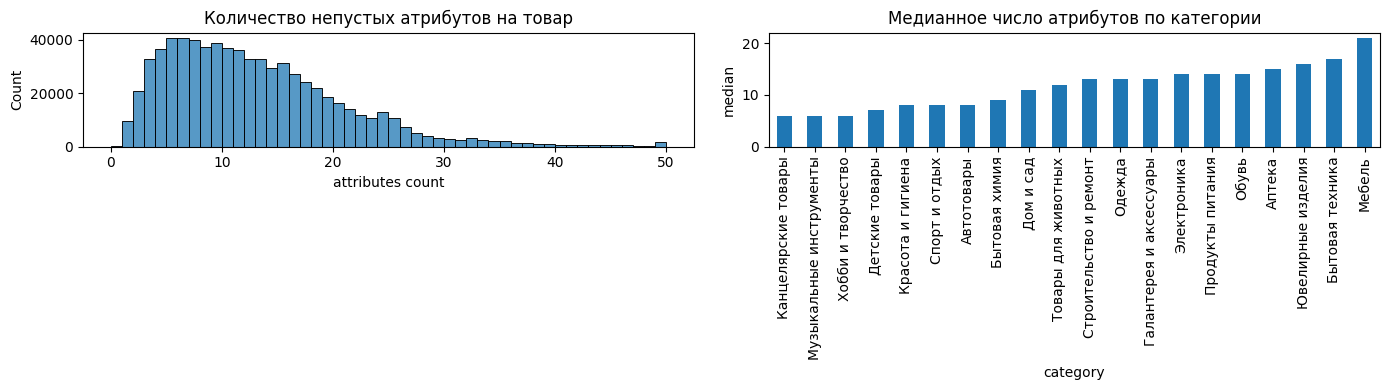

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(np.clip(items_per_attribute, 0, 50), bins=50, ax=axes[0])
axes[0].set(title='Количество непустых атрибутов на товар', xlabel='attributes count')
items.assign(attr_count=items_per_attribute).groupby('category').attr_count.median().sort_values().plot.bar(ax=axes[1])
axes[1].set(title='Медианное число атрибутов по категории', ylabel='median')
plt.tight_layout()


## 2. Частота, покрытие и кардинальность ключей

Хороший структурный признак должен встречаться достаточно часто внутри категории.
Кардинальность помогает отличить словарные поля (`цвет`, `материал`) от почти
уникальных идентификаторов (`артикул`) и потенциального мусора.


In [4]:
key_rows = []
for category, indices in items.groupby('category').groups.items():
    support = Counter()
    values = defaultdict(Counter)
    value_lengths = defaultdict(list)
    for index in indices:
        for key, value in attribute_dicts[index].items():
            support[key] += 1
            values[key][value] += 1
            value_lengths[key].append(len(value))
    category_size = len(indices)
    for key, count in support.items():
        key_rows.append({
            'category': category, 'key': key, 'support': count,
            'coverage': count/category_size, 'unique_values': len(values[key]),
            'unique_ratio': len(values[key])/count,
            'median_value_length': float(np.median(value_lengths[key])),
            'top_value_share': values[key].most_common(1)[0][1]/count,
        })
key_stats = pd.DataFrame(key_rows)
key_stats.to_csv(REPORT_DIR/'key_stats_by_category.csv', index=False)
display(key_stats.sort_values(['category','support'], ascending=[True,False]).groupby('category').head(10))


,category,key,support,coverage,unique_values,unique_ratio,median_value_length,top_value_share
3,Автотовары,тип,24470,0.648178,980,0.040049,17.0,0.091868
1,Автотовары,бренд,23379,0.619278,1312,0.056119,7.0,0.070619
2,Автотовары,партномер (артикул производителя),16130,0.427262,14988,0.929200,8.0,0.001240
15,Автотовары,комплектация,14386,0.381066,5221,0.362922,28.0,0.062283
0,Автотовары,артикул,10136,0.268489,10107,0.997139,12.0,0.000395
...,...,...,...,...,...,...,...,...
51089,Ювелирные изделия,бренд,21203,0.610000,582,0.027449,7.0,0.194737
51120,Ювелирные изделия,артикул,19184,0.551915,19020,0.991451,11.0,0.000365
51121,Ювелирные изделия,коллекция,18407,0.529561,228,0.012387,17.0,0.732765
51130,Ювелирные изделия,"средний вес изделия, гр",17598,0.506286,1450,0.082396,4.0,0.018241


In [5]:
global_keys = Counter(key for attrs in attribute_dicts for key in attrs)
global_key_stats = pd.DataFrame(global_keys.most_common(), columns=['key','support'])
global_key_stats['coverage'] = global_key_stats.support / len(items)
display(global_key_stats.head(40))


,key,support,coverage
0,тип,439699,0.618159
1,бренд,368270,0.517739
2,страна-изготовитель,284015,0.399288
3,комплектация,265374,0.373081
4,цвет товара,257174,0.361553
5,валюта,163743,0.230201
6,страна производства,152058,0.213774
7,пол,133153,0.187196
8,материал,120409,0.169279
9,состав,113286,0.159265


## 3. Семантические семейства

Точные имена ключей сильно различаются между категориями. Семейства дают
небольшое стабильное пространство признаков, но ниже мы всё равно отдельно
оцениваем лучшие точные ключи каждой категории.


In [6]:
FAMILY_PATTERNS = {
    'brand': r'бренд|brand|производител',
    'model': r'модель|model|серия|линейка',
    'identifier': r'артикул|партномер|part.?number|sku|mpn|oem|код товара',
    'size': r'размер|длина|ширина|высота|диаметр|толщина|габарит',
    'quantity': r'количеств|комплект|упаков|штук|шт\.?$|объем|объ.м|вес',
    'color': r'цвет|оттенок',
    'material': r'материал|состав|сырье|сырьё',
    'country': r'страна|производств',
    'seller_noise': r'продав|магазин|поставщик|валюта|цена|достав|гарант',
}
FAMILY_REGEX = {name: re.compile(pattern) for name, pattern in FAMILY_PATTERNS.items()}

def key_family(key):
    for family, pattern in FAMILY_REGEX.items():
        if pattern.search(key):
            return family
    return 'other'

key_stats['family'] = key_stats.key.map(key_family)
family_coverage = (key_stats.groupby(['category','family']).support.sum()
                   .reset_index().pivot(index='category', columns='family', values='support').fillna(0))
display(family_coverage)


family,brand,color,country,identifier,material,model,other,quantity,seller_noise,size
category,,,,,,,,,,
Автотовары,48999,15320,12995,28020,9437,10579,126283,38929,12315,44005
Аптека,23080,40869,21916,1006,55319,1950,308095,32485,5933,103246
Бытовая техника,28380,24871,21145,10063,19952,9554,310499,93667,30499,75767
Бытовая химия,23006,1955,23601,8614,17649,212,122592,65933,11047,32985
Галантерея и аксессуары,21937,40977,25547,3544,39876,3136,199928,56017,19474,66675
Детские товары,19657,18178,22501,3919,18849,1748,123592,29959,12152,38536
Дом и сад,22178,33055,23467,18618,29470,1123,131597,55519,12903,67945
Канцелярские товары,20661,23079,19775,995,13629,803,100848,39279,7575,22769
Красота и гигиена,20710,11886,25404,852,29896,684,127783,51446,12743,11027


## 4. Стратифицированная выборка пар

Сэмплируем внутри комбинации `category × target`, чтобы редкие категории и
положительные примеры не исчезли. Для финального расчёта переключите на все пары.


In [7]:
categories = items.set_index('id').category
pairs = matches.assign(category=matches.id1.map(categories))
if PAIR_SAMPLE_SIZE is not None and len(pairs) > PAIR_SAMPLE_SIZE:
    fraction = PAIR_SAMPLE_SIZE / len(pairs)
    pairs = (pairs.groupby(['category','target'], group_keys=False)
             .sample(frac=fraction, random_state=RANDOM_SEED)
             .reset_index(drop=True))
print(f'pair sample={len(pairs):,}')
display(pairs.groupby(['category','target']).size().unstack(fill_value=0))


pair sample=365,654


target,0.0,1.0
category,,
Автотовары,15684,3326
Аптека,16957,1328
Бытовая техника,11410,6404
Бытовая химия,9253,8183
Галантерея и аксессуары,14969,3015
Детские товары,7692,9869
Дом и сад,12966,4608
Канцелярские товары,11532,5903
Красота и гигиена,11003,6283


## 5. Pair-features из JSON

Строим компактные признаки без wide-table: общие ключи, точные совпадения,
конфликты, Jaccard ключей, совпадение/конфликт по семействам и числам.


In [8]:
attrs_by_id = dict(zip(items.id, attribute_dicts))

def family_values(attrs):
    result = defaultdict(set)
    for key, value in attrs.items():
        result[key_family(key)].add(value)
    return result

def pair_features(row):
    left, right = attrs_by_id[row.id1], attrs_by_id[row.id2]
    left_keys, right_keys = set(left), set(right)
    common = left_keys & right_keys
    matches_count = sum(left[k] == right[k] for k in common)
    conflicts = len(common) - matches_count
    union = left_keys | right_keys
    result = {
        'shared_keys': len(common),
        'key_jaccard': len(common)/max(1,len(union)),
        'matching_values': matches_count,
        'conflicting_values': conflicts,
        'value_match_ratio': matches_count/max(1,len(common)),
        'value_conflict_ratio': conflicts/max(1,len(common)),
    }
    lf, rf = family_values(left), family_values(right)
    for family in FAMILY_PATTERNS:
        lv, rv = lf.get(family,set()), rf.get(family,set())
        result[f'{family}_both'] = int(bool(lv and rv))
        result[f'{family}_match'] = int(bool(lv & rv))
        result[f'{family}_conflict'] = int(bool(lv and rv and not (lv & rv)))
    left_numbers = set(NUMBER_RE.findall(' '.join(left.values())))
    right_numbers = set(NUMBER_RE.findall(' '.join(right.values())))
    result['numeric_jaccard'] = len(left_numbers & right_numbers)/max(1,len(left_numbers | right_numbers))
    return result

started = time.perf_counter()
feature_rows = [pair_features(row) for row in pairs.itertuples(index=False)]
pair_feature_df = pd.concat([pairs.reset_index(drop=True), pd.DataFrame(feature_rows)], axis=1)
print(f'pair features in {time.perf_counter()-started:.1f}s')
pair_feature_df.to_parquet(REPORT_DIR/'pair_features_sample.parquet', index=False)
pair_feature_df.head()


pair features in 41.0s


,id1,id2,target,category,shared_keys,key_jaccard,matching_values,conflicting_values,value_match_ratio,value_conflict_ratio,...,material_both,material_match,material_conflict,country_both,country_match,country_conflict,seller_noise_both,seller_noise_match,seller_noise_conflict,numeric_jaccard
0,32,188978721454,0.0,Аптека,4,0.117647,1,3,0.250000,0.750000,...,1,1,0,0,0,0,0,0,0,0.266667
1,34,197568543106,0.0,Красота и гигиена,3,0.200000,2,1,0.666667,0.333333,...,0,0,0,0,0,0,0,0,0,0.000000
2,37,661425040668,0.0,Обувь,0,0.000000,0,0,0.000000,0.000000,...,0,0,0,1,1,0,0,0,0,0.000000
3,97,274877917548,0.0,Аптека,2,0.076923,1,1,0.500000,0.500000,...,1,0,1,1,1,0,0,0,0,0.666667
4,154,283467899529,0.0,Продукты питания,2,0.166667,1,1,0.500000,0.500000,...,0,0,0,0,0,0,0,0,0,0.000000


## 6. Одномерный сигнал и условные вероятности

AP используется только как ориентир ранжирующего сигнала. Бинарные conflict-
признаки могут быть полезны бустингу даже при невысоком одиночном AP.


In [9]:
feature_columns = [c for c in pair_feature_df.columns if c not in {'id1','id2','target','category'}]
rows = []
for feature in feature_columns:
    values = pair_feature_df[feature].fillna(0)
    rows.append({
        'feature': feature,
        'macro_ap': pair_feature_df.assign(_score=values).groupby('category').apply(
            lambda part: average_precision_score(part.target, part._score), include_groups=False).mean(),
        'positive_mean': values[pair_feature_df.target == 1].mean(),
        'negative_mean': values[pair_feature_df.target == 0].mean(),
    })
feature_signal = pd.DataFrame(rows).sort_values('macro_ap', ascending=False)
feature_signal.to_csv(REPORT_DIR/'pair_feature_signal.csv', index=False)
display(feature_signal)


,feature,macro_ap,positive_mean,negative_mean
33,numeric_jaccard,0.304110,0.148743,0.129059
4,value_match_ratio,0.271220,0.200862,0.233934
28,country_match,0.269001,0.325104,0.269771
7,brand_match,0.268228,0.087634,0.083256
22,color_match,0.267594,0.146448,0.168639
27,country_both,0.266118,0.385568,0.360169
2,matching_values,0.265842,0.494526,0.683527
9,model_both,0.263502,0.019033,0.033827
6,brand_both,0.263325,0.191256,0.208644
16,size_match,0.263008,0.035531,0.047188


In [10]:
condition_rows = []
for family in FAMILY_PATTERNS:
    for state in ['match','conflict']:
        column = f'{family}_{state}'
        selected = pair_feature_df[column].eq(1)
        condition_rows.append({
            'family': family, 'state': state, 'support': int(selected.sum()),
            'positive_rate': pair_feature_df.loc[selected,'target'].mean() if selected.any() else np.nan,
        })
family_conditions = pd.DataFrame(condition_rows)
family_conditions.to_csv(REPORT_DIR/'family_conditions.csv', index=False)
display(family_conditions)


,family,state,support,positive_rate
0,brand,match,30854,0.266675
1,brand,conflict,43805,0.222098
2,model,match,2401,0.160350
3,model,conflict,8579,0.163422
4,identifier,match,67,0.985075
5,identifier,conflict,17204,0.208847
6,size,match,16160,0.206436
7,size,conflict,158392,0.177004
8,quantity,match,30919,0.245221
9,quantity,conflict,168081,0.242276


## 7. Какие точные ключи действительно полезны

Для каждого достаточно частого ключа измеряем, насколько часто он присутствует
у обеих карточек и что означает точное совпадение либо конфликт. Рейтинг считается
отдельно внутри категории — ключ `модель` в электронике и `размер` в одежде не
обязаны иметь одинаковый смысл и покрытие.


In [11]:
candidate_keys = (key_stats[key_stats.support >= MIN_KEY_SUPPORT]
                  .sort_values(['category','support'], ascending=[True,False])
                  .groupby('category').head(TOP_KEYS_PER_CATEGORY)
                  .groupby('category').key.apply(list).to_dict())
exact_rows = []
for category, part in pairs.groupby('category'):
    for key in candidate_keys.get(category, []):
        both = equal = conflict = positives_equal = positives_conflict = 0
        for row in part.itertuples(index=False):
            left, right = attrs_by_id[row.id1], attrs_by_id[row.id2]
            if key not in left or key not in right:
                continue
            both += 1
            if left[key] == right[key]:
                equal += 1; positives_equal += int(row.target)
            else:
                conflict += 1; positives_conflict += int(row.target)
        exact_rows.append({
            'category': category, 'key': key, 'both_support': both,
            'equal_support': equal, 'conflict_support': conflict,
            'positive_rate_equal': positives_equal/equal if equal else np.nan,
            'positive_rate_conflict': positives_conflict/conflict if conflict else np.nan,
        })
exact_key_signal = pd.DataFrame(exact_rows)
exact_key_signal['rate_gap'] = exact_key_signal.positive_rate_equal - exact_key_signal.positive_rate_conflict
exact_key_signal.to_csv(REPORT_DIR/'exact_key_pair_signal.csv', index=False)
display(exact_key_signal.sort_values(['both_support','rate_gap'], ascending=False).head(80))


,category,key,both_support,equal_support,conflict_support,positive_rate_equal,positive_rate_conflict,rate_gap
570,Ювелирные изделия,проба,17418,16085,1333,0.127634,0.100525,0.027109
330,Обувь,сезон,14276,4107,10169,0.125883,0.080441,0.045442
571,Ювелирные изделия,вставка,13124,6036,7088,0.164844,0.095514,0.069331
390,Продукты питания,состав,11750,939,10811,0.293930,0.255851,0.038079
360,Одежда,российский размер,10935,775,10160,0.126452,0.064272,0.062180
...,...,...,...,...,...,...,...,...
379,Одежда,размер на модели,2395,536,1859,0.160448,0.058096,0.102352
287,Мебель,комплектация,2386,431,1955,0.067285,0.131969,-0.064684
454,Строительство и ремонт,цвет товара,2383,886,1497,0.124153,0.052104,0.072049
213,Канцелярские товары,цвет товара,2323,885,1438,0.358192,0.168289,0.189903


## 8. Потенциальный шум и итоговые кандидаты

`seller_noise` не удаляется автоматически: таблица ниже покажет его покрытие и
pair-сигнал. Удалять поле стоит только если оно высококардинально, нестабильно и
не даёт полезного conditional signal.


In [12]:
noise = key_stats[key_stats.family.eq('seller_noise')].sort_values('support', ascending=False)
display(noise.head(60))

recommended = exact_key_signal[
    (exact_key_signal.both_support >= 200) &
    (exact_key_signal.rate_gap.abs() >= 0.10)
].sort_values(['category','rate_gap'], ascending=[True,False])
recommended.to_csv(REPORT_DIR/'recommended_exact_keys.csv', index=False)
display(recommended.groupby('category').head(15))


,category,key,support,coverage,unique_values,unique_ratio,median_value_length,top_value_share,family
3306,Бытовая техника,гарантийный срок,19548,0.560323,681,0.034837,6.0,0.304174,seller_noise
44187,Электроника,гарантийный срок,17804,0.516732,709,0.039823,6.0,0.276174,seller_noise
22056,Мебель,гарантийный срок,15954,0.449345,246,0.015419,7.0,0.285571,seller_noise
20526,Красота и гигиена,валюта,12484,0.363976,1,0.000080,3.0,1.000000,seller_noise
25995,Одежда,валюта,11829,0.257836,1,0.000085,3.0,1.000000,seller_noise
10638,Галантерея и аксессуары,валюта,11028,0.311227,1,0.000091,3.0,1.000000,seller_noise
41171,Товары для животных,валюта,10985,0.308022,1,0.000091,3.0,1.000000,seller_noise
9789,Бытовая химия,валюта,10924,0.328206,1,0.000092,3.0,1.000000,seller_noise
26898,Продукты питания,валюта,9807,0.275756,1,0.000102,3.0,1.000000,seller_noise
11795,Детские товары,валюта,9565,0.274927,1,0.000105,3.0,1.000000,seller_noise


,category,key,both_support,equal_support,conflict_support,positive_rate_equal,positive_rate_conflict,rate_gap
27,Автотовары,индекс нагрузки,1344,258,1086,0.492248,0.051565,0.440683
21,Автотовары,название цвета,250,3,247,0.333333,0.068826,0.264507
26,Автотовары,особенности,854,33,821,0.333333,0.171742,0.161592
3,Автотовары,комплектация,2932,313,2619,0.325879,0.166858,0.159021
25,Автотовары,сезонность,1424,162,1262,0.265432,0.127575,0.137857
...,...,...,...,...,...,...,...,...
542,Электроника,комплектация,5874,951,4923,0.027340,0.135283,-0.107944
576,Ювелирные изделия,артикул,1654,22,1632,1.000000,0.132353,0.867647
589,Ювелирные изделия,покрытие,217,44,173,0.272727,0.092486,0.180242
574,Ювелирные изделия,комплектация,8059,874,7185,0.210526,0.079889,0.130638


## Как использовать результаты в следующем эксперименте

Предлагаемый первый boosting-набор:

1. cosine similarity Qwen3-Embedding для `name`;
2. `abs(e1-e2)` после PCA до 32–64 компонент либо только агрегаты;
3. name lexical features из существующего EDA;
4. компактные JSON pair-features из секции 5;
5. match/conflict для рекомендованных точных ключей своей категории;
6. категория как categorical feature в CatBoost.

Отдельные item embeddings вычисляются один раз на уникальный товар и затем
join-ятся к парам. Сначала сравниваем `name embeddings + lexical`, затем добавляем
структурные attributes. Полный сырой JSON в первый embedding-прогон не добавляем:
иначе невозможно понять источник прироста и растёт стоимость инференса.


In [13]:
summary = {
    'items': len(items), 'pairs_analyzed': len(pairs),
    'unique_attribute_keys': len(global_keys),
    'median_attributes_per_item': float(np.median(items_per_attribute)),
    'recommended_exact_keys': len(recommended),
    'pair_sample_size_setting': PAIR_SAMPLE_SIZE,
}
(REPORT_DIR/'summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
summary


{'items': 711304,
 'pairs_analyzed': 365654,
 'unique_attribute_keys': 33990,
 'median_attributes_per_item': 11.0,
 'recommended_exact_keys': 75,
 'pair_sample_size_setting': None}